In [1]:
import json
import pickle
from typing import cast

import matplotlib.pyplot as plt
import pandas as pd

from aare.evaluation.eval_metric import EvalMetric
from aare.evaluation.forecast_samples import ForecastSamples
from aare.utils import FORECAST_SAMPLES_FOLDER, METRICS_FOLDER

plt.rcParams["figure.figsize"] = (16, 9)

/home/joel/projects/aare-forecast/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


# Baseline showcase

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def plot_from_file(path, title: str):
    with open(path, "rb") as file:
        sample = cast(ForecastSamples, pickle.load(file))

    print(type(sample))

    return sample.plot(title)

In [4]:
def plot_baseline(model: str):
    plot_from_file(FORECAST_SAMPLES_FOLDER / f"{model}.pkl", model)

In [5]:
def read_metrics(path, as_dict=False):
    with open(path, "rt") as file:
        raw = json.load(file)
        if as_dict:
            return raw

        return EvalMetric.from_dict(raw)

In [6]:
def combine_metrics(*models: str):
    metrics = []
    for model in models:
        metrics.append(read_metrics(METRICS_FOLDER / f"{model}.json", as_dict=True) | dict(name=model))

    return pd.DataFrame(metrics).set_index("name")

These are the aggregate metrics for each baseline model over the entire validation period using a strided evaluation (see params.yaml for stride). The mae and rmse values are the median of all the forecasts the model has made for the validation period.

In [7]:
combine_metrics("LOCF", "MEAN", "SNAIVE", "TIMESFM")

,mae,rmse,madpd,mae_std,rmse_std,madpd_std
name,,,,,,
LOCF,0.685526,0.851304,0.999870,0.546967,0.613594,0.905241
MEAN,0.825646,0.982233,0.870901,0.545037,0.591939,0.888271
SNAIVE,0.614726,0.727719,0.568976,0.495445,0.557795,0.523320
TIMESFM,0.576848,0.690817,0.608091,0.486596,0.552405,0.550814


<class 'aare.evaluation.forecast_samples.ForecastSamples'>


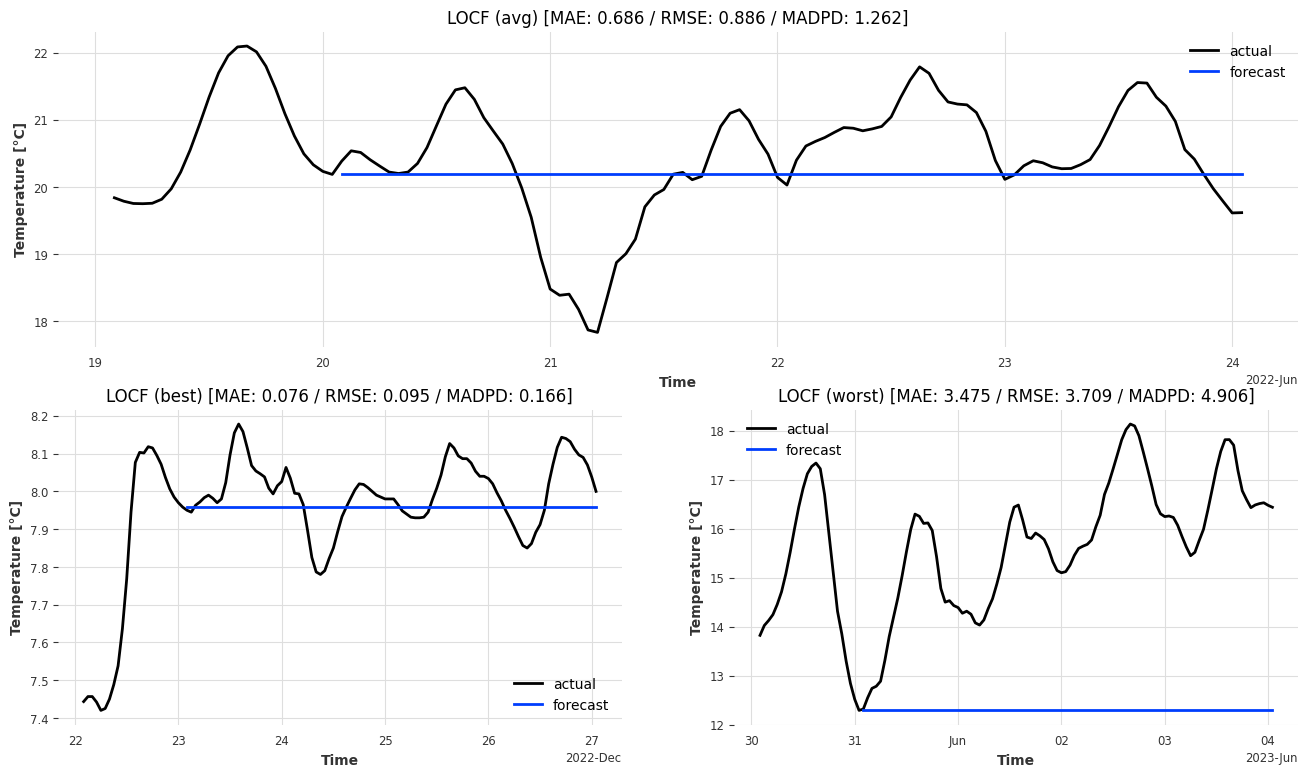

In [8]:
plot_baseline("LOCF")

<class 'aare.evaluation.forecast_samples.ForecastSamples'>


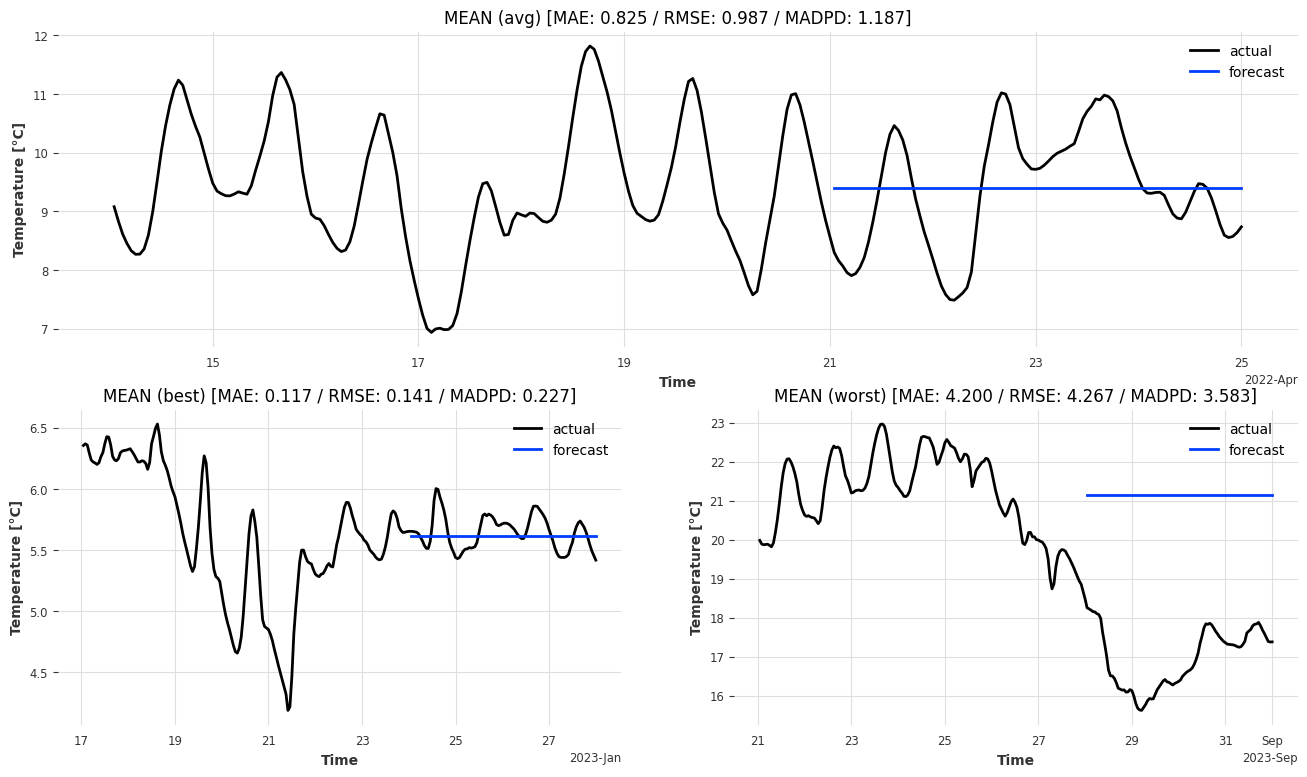

In [9]:
plot_baseline("MEAN")

<class 'aare.evaluation.forecast_samples.ForecastSamples'>


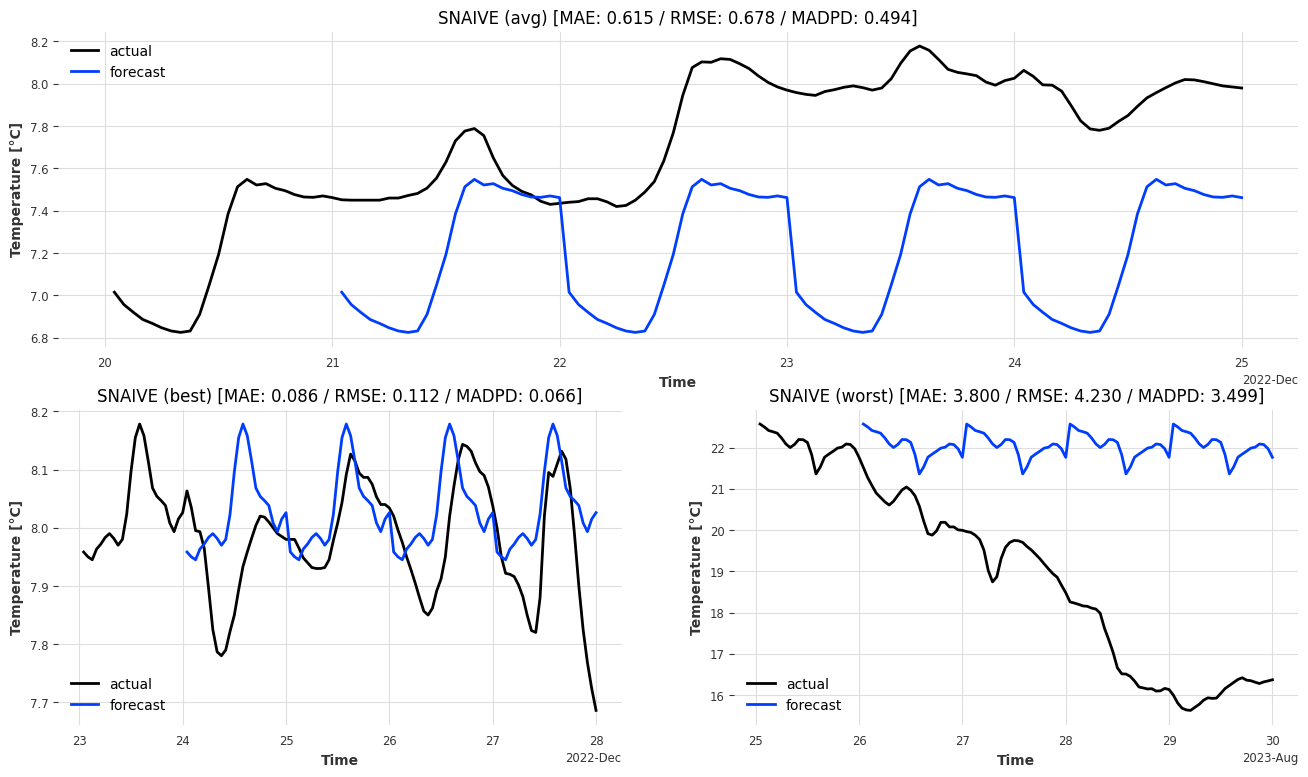

In [10]:
plot_baseline("SNAIVE")

<class 'aare.evaluation.forecast_samples.ForecastSamples'>


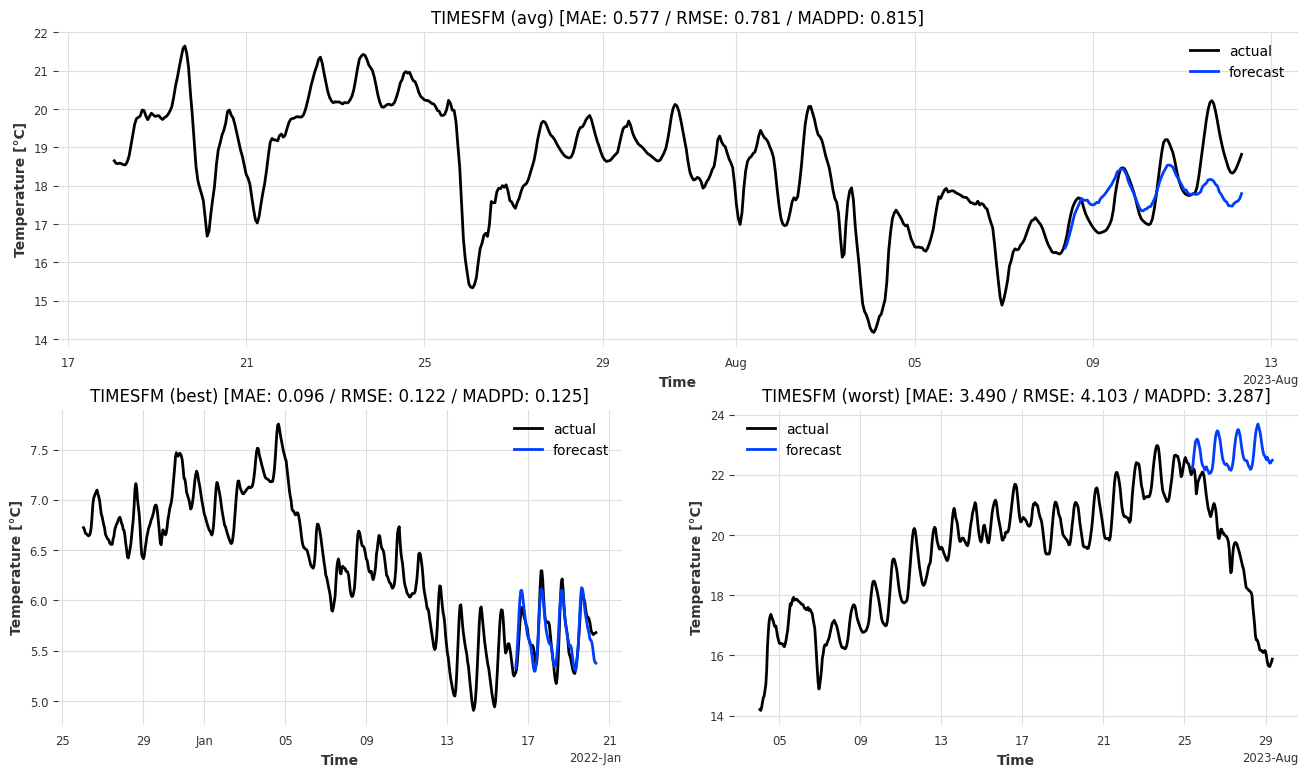

In [11]:
plot_baseline("TIMESFM")